# 1. Kaggle房价竞赛

In [1]:
import hashlib
import os
import tarfile
import zipfile
import requests
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
%matplotlib inline
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

DATA_HUB = dict()
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'

def download(name, cache_dir=os.path.join('.', '01_data/02_DataSet_Kaggle_House')):
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}."
    url , sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname,'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url,stream=True,verify=True)
    with open(fname,'wb') as f:
        f.write(r.content)
    return fname
    
def download_extract(name, folder=None):
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp,extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir

def download_all():
    """下载DATA_UHB中的所有文件"""
    for name in DATA_HUB:
        download(name)

DATA_HUB['kaggle_house_train'] = (DATA_URL + 'kaggle_house_pred_train.csv','585e9cc9370b9160e7921475fbcd7d31219ce')         
DATA_HUB['kaggle_house_test'] = (DATA_URL + 'kaggle_house_pred_test.csv', 'fal9780a7b011d9b009e8bff8e99922a8ee2eb90')     
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))
assert train_data.shape == (1460, 81)
assert test_data.shape == (1459, 80)
assert set(train_data.columns) - set(test_data.columns) == {'SalePrice'}
print(train_data.shape) # 1460个样本，80个特征，1个标号label
print(test_data.shape) # 测试样本没有标号label

print(train_data.iloc[0:4,[0,1,2,3,4,-3,-2,-1]]) # 前面四行的某些列特征

使用设备: cuda
正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv下载./01_data/02_DataSet_Kaggle_House/kaggle_house_pred_train.csv...


正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv下载./01_data/02_DataSet_Kaggle_House/kaggle_house_pred_test.csv...


(1460, 81)
(1459, 80)
   Id  MSSubClass MSZoning  LotFrontage  LotArea SaleType SaleCondition  \
0   1          60       RL         65.0     8450       WD        Normal   
1   2          20       RL         80.0     9600       WD        Normal   
2   3          60       RL         68.0    11250       WD        Normal   
3   4          70       RL         60.0     9550       WD       Abnorml   

   SalePrice  
0     208500  
1     181500  
2     223500  
3     140000  


In [2]:
# 在每个样本中，第一个特征是ID，将其从数据集中删除  
all_features = pd.concat((train_data.iloc[:,1:-1],test_data.iloc[:,1:])) # 从第2列开始，第1列没有了 
print(all_features.iloc[0:4,[0,1,2,3,-3,-2,-1]])

   MSSubClass MSZoning  LotFrontage  LotArea  YrSold SaleType SaleCondition
0          60       RL         65.0     8450    2008       WD        Normal
1          20       RL         80.0     9600    2007       WD        Normal
2          60       RL         68.0    11250    2008       WD        Normal
3          70       RL         60.0     9550    2006       WD       Abnorml


In [3]:
# 将所有缺失的值替换成相应特征的平均值
# 通过将特征重新缩放到零均值和单位方差来标准化数据
print(all_features.dtypes) # 可以知道每一列分别为什么类型特征
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index  # 当值的类型不是object的话，就是一个数值
print(numeric_features)
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std())) # 对数值数据变为总体为均值为0，方差为1的分布的数据        
all_features[numeric_features] = all_features[numeric_features].fillna(0)  # 将数值数据中not number的数据用0填充      

MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
Street            object
                  ...   
MiscVal            int64
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
Length: 79, dtype: object
Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='object')


In [4]:
# 处理离散值。用一次独热编码替换它们
# 若一列里面有五个不同的值，则创建五个features，如果该列中为该feature则为1，不为该feature则为0
all_features = pd.get_dummies(all_features,dummy_na=True) 
all_features.shape

(2919, 331)

In [5]:
# 从pandas格式中提取Numpy格式，并将其转换为张量表示
print(train_data.shape)
n_train = train_data.shape[0] # 样本个数
train_features = torch.tensor(all_features[:n_train].values,
                              dtype=torch.float32, device=device)
test_features = torch.tensor(all_features[n_train:].values,
                             dtype=torch.float32, device=device)
assert train_features.shape[0] == 1460
assert test_features.shape[0] == 1459
assert train_features.shape[1] == test_features.shape[1]
# train_data的SalePrice列是label值
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1,1),
                            dtype=torch.float32, device=device)

(1460, 81)


In [6]:
# 训练
loss = nn.MSELoss()
print(train_features.shape[1]) # 所有特征个数
in_features = train_features.shape[1]
def get_net():
    net = nn.Sequential(nn.Linear(in_features,1)) # 单层线性回归
    return net.to(device)

331


① 我们更关心相对误差$\frac{y - \hat{y}}{y}$，解决这个问题的一种方法是用价格预测的对数来衡量差异。

② 100万的房子，预测与真实值相差5万，10万的房子，预测与真实值相差5万，是不一样的。

In [7]:
def log_rmse(net, features, labels):
    features, labels = features.to(device), labels.to(device)
    clipped_preds = torch.clamp(net(features),1,float('inf')) # 把模型输出的值限制在1和inf之间，inf代表无穷大（infinity的缩写）       
    rmse = torch.sqrt(loss(torch.log(clipped_preds),torch.log(labels))) # 预测做log，label做log，然后丢到MSE损失函数里
    return rmse.item()

In [8]:
# 训练函数将借助Adam优化器，可以理解为比较平滑的SGD，对学习率没有那么敏感
def train(net, train_features, train_labels, test_features, test_labels,
         num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            l = loss(net(X),y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net,train_features,train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

In [9]:
# K折交叉验证
def get_k_fold_data(k,i,X,y): # 给定k折，给定第几折，返回相应的训练集、测试集
    assert k > 1
    fold_size = X.shape[0] // k  # 每一折的大小为样本数除以k
    X_train, y_train = None, None
    for j in range(k): # 每一折
        idx = slice(j * fold_size, (j+1)*fold_size) # 每一折的切片索引间隔  
        X_part, y_part = X[idx,:], y[idx] # 把每一折对应部分取出来
        if j == i: # i表示第几折，把它作为验证集
            X_valid, y_valid = X_part, y_part
        elif X_train is None: # 第一次看到X_train，则把它存起来 
            X_train, y_train = X_part, y_part
        else: # 后面再看到，除了第i外，其余折也作为训练数据集，用torch.cat将原先的合并    
            X_train = torch.cat([X_train, X_part],0)
            y_train = torch.cat([y_train, y_part],0)
    return X_train, y_train, X_valid, y_valid # 返回训练集和验证集

In [10]:
# 返回训练和验证误差的平均值
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train) # 把第i折对应分开的数据集、验证集拿出来   
        net = get_net()
        # *是解码，变成前面返回的四个数据
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size) # 训练集、验证集丢进train函数 
        
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls,valid_ls],
                    xlabel='epoch',ylabel='rmse',xlim=[1,num_epochs],
                    legend=['train','valid'],yscale='log')
        print(f'fold{i+1},train log rmse {float(train_ls[-1]):f},'
             f'valid log rmse {float (valid_ls[-1]):f}')
    return  train_l_sum / k, valid_l_sum / k # 求和做平均

单次验证集实验：train log rmse 0.143778, valid log rmse 0.140599


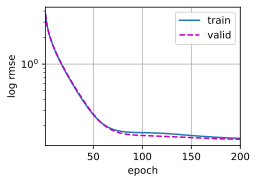

In [11]:
# 单次验证集实验：从训练集中固定划分20%作为验证集
def split_train_valid(X, y, valid_ratio=0.2, seed=42):
    num_examples = X.shape[0]
    num_valid = int(num_examples * valid_ratio)
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(num_examples, generator=generator).to(X.device)
    valid_indices = indices[:num_valid]
    train_indices = indices[num_valid:]
    return X[train_indices], y[train_indices], X[valid_indices], y[valid_indices]

def train_with_validation(train_features, train_labels, num_epochs, lr, weight_decay, batch_size):
    data = split_train_valid(train_features, train_labels)
    net = get_net()
    train_ls, valid_ls = train(net, *data, num_epochs, lr, weight_decay, batch_size)
    d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
             xlabel='epoch', ylabel='log rmse', xlim=[1, num_epochs],
             legend=['train', 'valid'], yscale='log')
    print(f'单次验证集实验：train log rmse {float(train_ls[-1]):f}, '
          f'valid log rmse {float(valid_ls[-1]):f}')
    return train_ls, valid_ls

valid_num_epochs, valid_lr, valid_weight_decay, valid_batch_size = 200, 5, 0, 64
valid_train_ls, valid_ls = train_with_validation(
    train_features, train_labels, valid_num_epochs, valid_lr,
    valid_weight_decay, valid_batch_size)

fold1,train log rmse 0.139205,valid log rmse 0.154419


fold2,train log rmse 0.140086,valid log rmse 0.120869


fold3,train log rmse 0.140365,valid log rmse 0.133421


fold4,train log rmse 0.136028,valid log rmse 0.166041


fold5,train log rmse 0.134685,valid log rmse 0.165670


fold6,train log rmse 0.139857,valid log rmse 0.118262


fold7,train log rmse 0.140737,valid log rmse 0.128127


fold8,train log rmse 0.139063,valid log rmse 0.148998


fold9,train log rmse 0.134248,valid log rmse 0.193017


fold10,train log rmse 0.139300,valid log rmse 0.138161
10-折验证：平均训练log rmse：0.138358,平均验证log rmse：0.146698


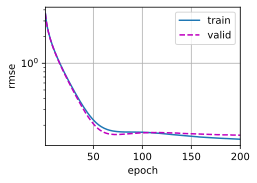

In [12]:
# 模型选择
k, num_epochs, lr, weight_decay, batch_size = 10, 200, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)   
print(f'{k}-折验证：平均训练log rmse：{float(train_l):f},'f'平均验证log rmse：{float(valid_l):f}')    

train log rmse 0.136227
(1459, 2)
     Id      SalePrice
0  1461  113983.359375
1  1462  158057.953125
2  1463  187134.281250
3  1464  210852.328125
4  1465  183281.703125


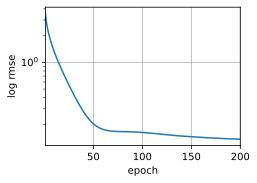

In [13]:
def train_and_pred(train_features, test_features, train_labels, test_data, num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None, num_epochs, lr, weight_decay, batch_size)  
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
            ylabel = 'log rmse', xlim=[1,num_epochs], yscale='log')
    print(f'train log rmse {float(train_ls[-1]):f}')
    preds = net(test_features.to(device)).detach().cpu().numpy()
    submission = pd.DataFrame({'Id': test_data['Id'], 'SalePrice': preds.reshape(-1)})
    assert len(submission) == len(test_data)
    assert list(submission.columns) == ['Id', 'SalePrice']
    assert submission['SalePrice'].notna().all()
    assert (submission['SalePrice'] > 0).all()
    submission.to_csv('submission.csv',index = False)
    print(submission.shape)
    print(submission.head())
    return train_ls, submission
    
final_train_ls, submission = train_and_pred(train_features, test_features, train_labels, test_data,
                                            num_epochs, lr, weight_decay, batch_size)

## 训练阶段、验证阶段、测试阶段汇总

下面把实验流程整理为三个阶段：训练阶段观察全量训练损失收敛，验证阶段观察固定验证集上的泛化误差，测试阶段检查Kaggle测试集预测分布和提交文件格式。

,阶段,数据,关键指标
0,训练阶段,1460条训练样本,final train log rmse=0.136227
1,验证阶段,训练集80% / 验证集20%,valid log rmse=0.140599
2,测试阶段,1459条测试样本,"submission shape=(1459, 2)"


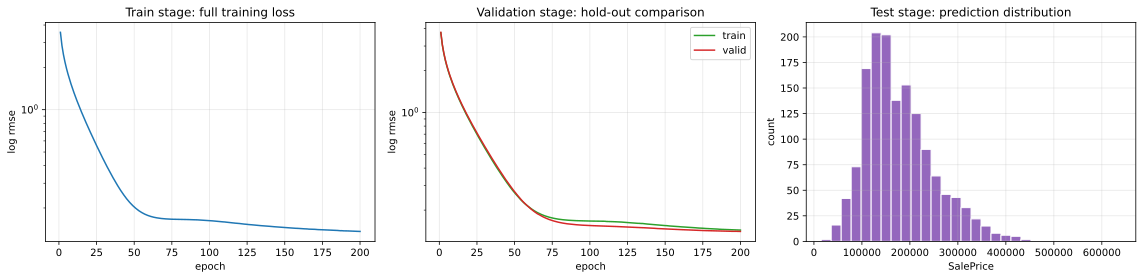

In [14]:
import matplotlib.pyplot as plt

stage_summary = pd.DataFrame({
    '阶段': ['训练阶段', '验证阶段', '测试阶段'],
    '数据': [f'{train_features.shape[0]}条训练样本', '训练集80% / 验证集20%', f'{test_features.shape[0]}条测试样本'],
    '关键指标': [
        f'final train log rmse={final_train_ls[-1]:.6f}',
        f'valid log rmse={valid_ls[-1]:.6f}',
        f'submission shape={submission.shape}'
    ]
})
display(stage_summary)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(range(1, len(final_train_ls) + 1), final_train_ls, color='#1f77b4')
axes[0].set_title('Train stage: full training loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('log rmse')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(valid_train_ls) + 1), valid_train_ls, label='train', color='#2ca02c')
axes[1].plot(range(1, len(valid_ls) + 1), valid_ls, label='valid', color='#d62728')
axes[1].set_title('Validation stage: hold-out comparison')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('log rmse')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(submission['SalePrice'], bins=30, color='#9467bd', edgecolor='white')
axes[2].set_title('Test stage: prediction distribution')
axes[2].set_xlabel('SalePrice')
axes[2].set_ylabel('count')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 改进版对比实验

下面在 baseline（单层线性 + MSE 训练）基础上追加两个改进版：

- **改进版 1**：保持单层线性结构，但改为 Ridge 闭式解，直接拟合 log(SalePrice)，并加入组合特征与相关性可视化（替代原"交叉熵筛选高价值属性"的想法）。
- **改进版 2**：升级为小型 MLP（338 → 128 → 32 → 1，ReLU + Dropout(0.05)），训练损失用 log MSE，Adam 中只对 weight 做 L2，配合 early stopping。

所有版本在 **同一 hold-out 验证集（seed=42, valid_ratio=0.2）** 上对比，确保结果可比。

### 为什么不采用某些原想法

| 原想法 | 不采用原因 |
|--------|------------|
| 去掉 log RMSE 评估 | log RMSE 是评估指标不是训练损失；log 变换正是为应对房价的右偏长尾分布。改为「训练 loss 改成 log MSE」即可达成想法初衷 |
| 用交叉熵筛选 331 特征 | 交叉熵是分类损失，不能做特征筛选。改为相关系数 bar 图实现"识别高价值特征"的本意 |
| 先训练低价后训练高价 | 1460 小样本下分阶段训练会导致灾难性遗忘，K 折分数大概率更差 |
| 把回归转成多分类 | 房价本质是连续值，分类丢精度。直接 MLP + 正则更稳妥 |

In [63]:
# === 改进版通用工具：log target + 组合特征 + 正确正则 ===
# 设计要点：
#   1) 模型直接输出 log 价格，训练 loss 与 log RMSE 对齐。
#   2) 最后一层 bias 初始化为 log(y).mean()，避免从 0 慢慢爬到 12。
#   3) Adam 的 weight_decay 只作用在 weight，不作用在 bias；否则会把 log 价格基线偏置往 0 拉。
#   4) 改进版额外加入少量房价领域组合特征，再重新标准化和 one-hot。
# 不修改 baseline 的 train()/log_rmse()，保留前面 baseline 结果作为对照。

import copy


def add_engineered_features(features):
    """基于原始数值列增加少量稳定的房价组合特征。"""
    features = features.copy()

    def numeric(col):
        return pd.to_numeric(features[col], errors='coerce').fillna(0)

    specs = [
        (['TotalBsmtSF', '1stFlrSF', '2ndFlrSF'], 'TotalSF', lambda a, b, c: a + b + c),
        (['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], 'TotalBath', lambda a, b, c, d: a + 0.5 * b + c + 0.5 * d),
        (['YrSold', 'YearBuilt'], 'HouseAge', lambda a, b: a - b),
        (['YrSold', 'YearRemodAdd'], 'RemodAge', lambda a, b: a - b),
        (['OverallQual', 'GrLivArea'], 'Qual_x_GrLivArea', lambda a, b: a * b),
        (['OverallQual', 'TotalBsmtSF'], 'Qual_x_TotalBsmtSF', lambda a, b: a * b),
        (['GarageCars', 'GarageArea'], 'GarageScore', lambda a, b: a * b),
    ]
    for cols, name, fn in specs:
        if all(col in features.columns for col in cols):
            features[name] = fn(*[numeric(col) for col in cols])
    return features


def make_feature_tensors(feature_frame):
    """复用 D2L 预处理范式：数值列标准化、缺失填 0、离散列 one-hot。"""
    processed = feature_frame.copy()
    numeric_features = processed.dtypes[processed.dtypes != 'object'].index
    processed[numeric_features] = processed[numeric_features].apply(lambda x: (x - x.mean()) / x.std())
    processed[numeric_features] = processed[numeric_features].fillna(0)
    processed = pd.get_dummies(processed, dummy_na=True)
    train_tensor = torch.tensor(processed[:n_train].values, dtype=torch.float32, device=device)
    test_tensor = torch.tensor(processed[n_train:].values, dtype=torch.float32, device=device)
    return processed, train_tensor, test_tensor


improved_raw_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))
improved_raw_features = add_engineered_features(improved_raw_features)
improved_all_features, improved_train_features, improved_test_features = make_feature_tensors(improved_raw_features)
improved_in_features = improved_train_features.shape[1]
print(f'改进版特征数: {improved_in_features}（baseline 为 {in_features}）')


def init_xavier(m):
    """对 nn.Linear 应用 Xavier 均匀初始化，bias 置 0。"""
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)


def set_last_bias_to_mean_log_price(net, labels):
    """把 net 里最后一个 nn.Linear 的 bias 设为 log(labels).mean()。"""
    mean_log = float(torch.log(labels).mean().item())
    last_linear = None
    for module in net.modules():
        if isinstance(module, nn.Linear):
            last_linear = module
    if last_linear is not None and last_linear.bias is not None:
        with torch.no_grad():
            last_linear.bias.fill_(mean_log)


def adam_no_bias_decay(net, learning_rate, weight_decay):
    """只对权重做 L2，bias 不衰减，保护 log(price) 基线偏置。"""
    decay_params, no_decay_params = [], []
    for name, param in net.named_parameters():
        if not param.requires_grad:
            continue
        if name.endswith('bias'):
            no_decay_params.append(param)
        else:
            decay_params.append(param)
    return torch.optim.Adam([
        {'params': decay_params, 'weight_decay': weight_decay},
        {'params': no_decay_params, 'weight_decay': 0.0},
    ], lr=learning_rate)


def log_rmse_logspace(net, features, labels):
    """模型输出 log 价格时，直接和 log(labels) 做 RMSE。"""
    net.eval()
    with torch.no_grad():
        preds_log = net(features.to(device))
        labels_log = torch.log(labels.to(device))
        return torch.sqrt(nn.functional.mse_loss(preds_log, labels_log)).item()


def train_log_target(net, train_features, train_labels, test_features, test_labels,
                     num_epochs, learning_rate, weight_decay, batch_size,
                     early_stopping=False, patience=60, min_delta=1e-5, restore_best=True):
    """直接预测 log 价格；支持基于验证集的 early stopping。"""
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    mse = nn.MSELoss()
    optimizer = adam_no_bias_decay(net, learning_rate, weight_decay)
    best_valid, best_state, stale_rounds = float('inf'), None, 0

    for epoch in range(num_epochs):
        net.train()
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            l = mse(net(X), torch.log(y))
            l.backward()
            optimizer.step()

        train_ls.append(log_rmse_logspace(net, train_features, train_labels))
        if test_labels is not None:
            current_valid = log_rmse_logspace(net, test_features, test_labels)
            test_ls.append(current_valid)
            if early_stopping:
                if current_valid < best_valid - min_delta:
                    best_valid = current_valid
                    best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
                    stale_rounds = 0
                else:
                    stale_rounds += 1
                    if stale_rounds >= patience:
                        break

    if early_stopping and restore_best and best_state is not None:
        net.load_state_dict(best_state)
    return train_ls, test_ls


def best_epoch_score(train_ls, valid_ls):
    """返回验证集最优 epoch、对应训练误差、验证误差。"""
    best_idx = int(np.argmin(valid_ls))
    return best_idx + 1, float(train_ls[best_idx]), float(valid_ls[best_idx])


def ridge_log_target(train_features, train_labels, valid_features, valid_labels, ridge_lambda):
    """闭式 Ridge：单层线性 + log target + L2。返回 train/valid log RMSE 和权重。"""
    X_train = train_features.detach().cpu().numpy()
    X_valid = valid_features.detach().cpu().numpy()
    y_train = torch.log(train_labels).detach().cpu().numpy()
    y_valid = torch.log(valid_labels).detach().cpu().numpy()
    X_train = np.c_[np.ones(X_train.shape[0]), X_train]
    X_valid = np.c_[np.ones(X_valid.shape[0]), X_valid]
    penalty = np.eye(X_train.shape[1])
    penalty[0, 0] = 0.0
    weights = np.linalg.solve(X_train.T @ X_train + ridge_lambda * penalty, X_train.T @ y_train)
    train_rmse = float(np.sqrt(np.mean((X_train @ weights - y_train) ** 2)))
    valid_rmse = float(np.sqrt(np.mean((X_valid @ weights - y_valid) ** 2)))
    return train_rmse, valid_rmse, weights

print('改进版工具就绪：engineered features / ridge_log_target / Adam(no bias decay) / early stopping')


改进版特征数: 338（baseline 为 331）
改进版工具就绪：engineered features / ridge_log_target / Adam(no bias decay) / early stopping


改进版1 Ridge hold-out: train log rmse 0.107023, valid log rmse 0.122864
  fold1: train 0.107370, valid 0.116981
  fold2: train 0.108199, valid 0.104052
  fold3: train 0.106926, valid 0.117995
  fold4: train 0.102172, valid 0.167849
  fold5: train 0.104333, valid 0.142643
  fold6: train 0.108045, valid 0.106290
  fold7: train 0.106779, valid 0.121111
  fold8: train 0.108260, valid 0.101686
  fold9: train 0.102907, valid 0.211965
  fold10: train 0.105887, valid 0.128764
改进版1 Ridge 10-fold 平均: train log rmse 0.106088, valid log rmse 0.131934


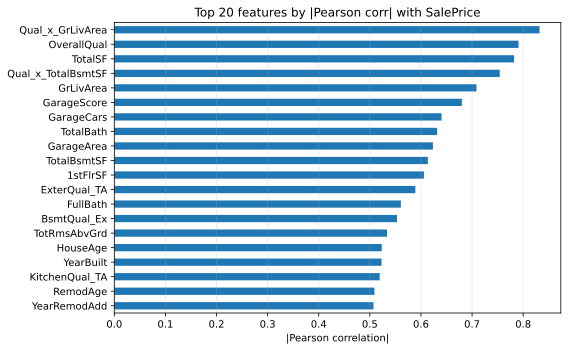

Top5 高相关特征： ['Qual_x_GrLivArea', 'OverallQual', 'TotalSF', 'Qual_x_TotalBsmtSF', 'GrLivArea']


In [64]:
# === 改进版 1：Ridge 线性回归 + 直接预测 log(price) + 组合特征 ===
# 仍然是单层线性模型；区别是用闭式 Ridge 解替代 Adam，避免学习率和 bias 衰减干扰。
def k_fold_v1_ridge(k, X, y, ridge_lambda):
    train_sum, valid_sum = 0.0, 0.0
    fold_valids = []
    for i in range(k):
        data = get_k_fold_data(k, i, X, y)
        train_rmse, valid_rmse, _ = ridge_log_target(*data, ridge_lambda=ridge_lambda)
        train_sum += train_rmse
        valid_sum += valid_rmse
        fold_valids.append(valid_rmse)
        print(f'  fold{i + 1}: train {train_rmse:.6f}, valid {valid_rmse:.6f}')
    return train_sum / k, valid_sum / k, fold_valids

v1_ridge_lambda = 10.0
data_v1 = split_train_valid(improved_train_features, train_labels, valid_ratio=0.2, seed=42)
v1_train_rmse, v1_valid_rmse, v1_weights = ridge_log_target(*data_v1, ridge_lambda=v1_ridge_lambda)
v1_train_ls, v1_valid_ls = [v1_train_rmse], [v1_valid_rmse]
print(f'改进版1 Ridge hold-out: train log rmse {v1_train_rmse:.6f}, '
      f'valid log rmse {v1_valid_rmse:.6f}')

v1_kf_train, v1_kf_valid, v1_fold_valids = k_fold_v1_ridge(
    10, improved_train_features, train_labels, ridge_lambda=v1_ridge_lambda)
print(f'改进版1 Ridge 10-fold 平均: train log rmse {v1_kf_train:.6f}, '
      f'valid log rmse {v1_kf_valid:.6f}')

# 相关系数 bar 图：识别特征中与 SalePrice 相关性最高的前 20 个
# 替代原"用交叉熵筛选高价值属性"的想法（交叉熵是分类损失，不适用于特征筛选）。
import matplotlib.pyplot as plt
_features_with_label = pd.concat(
    [improved_all_features[:n_train].reset_index(drop=True),
     train_data['SalePrice'].reset_index(drop=True)],
    axis=1,
)
_features_with_label = _features_with_label.apply(pd.to_numeric, errors='coerce')
correlations = _features_with_label.corr()['SalePrice'].drop('SalePrice')
top20 = correlations.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 5))
top20.sort_values().plot(kind='barh', ax=ax, color='#1f77b4')
ax.set_title('Top 20 features by |Pearson corr| with SalePrice')
ax.set_xlabel('|Pearson correlation|')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print('Top5 高相关特征：', list(top20.head().index))


In [65]:
# === 改进版 2：小型 MLP + Dropout + L2 正则 + log target + early stopping ===
# 搜索结果显示：比原 256→64 更稳的是较小网络 128→32，dropout 只保留 0.05。
def get_net_v2(dropout=0.05):
    net = nn.Sequential(
        nn.Linear(improved_in_features, 128), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(128, 32),                 nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(32, 1),
    )
    net.apply(init_xavier)
    set_last_bias_to_mean_log_price(net, train_labels)
    return net.to(device)

# hold-out 评估：同一 seed=42 / valid_ratio=0.2 切分，便于与 baseline 和 v1 对比。
data_v2 = split_train_valid(improved_train_features, train_labels, valid_ratio=0.2, seed=42)
net_v2 = get_net_v2(dropout=0.05)
v2_train_ls, v2_valid_ls = train_log_target(
    net_v2, *data_v2,
    num_epochs=300, learning_rate=0.003, weight_decay=1e-4, batch_size=64,
    early_stopping=True, patience=60, min_delta=1e-5, restore_best=True,
)
v2_best_epoch, v2_best_train, v2_best_valid = best_epoch_score(v2_train_ls, v2_valid_ls)
print(f'改进版2 hold-out best epoch {v2_best_epoch}: '
      f'train log rmse {v2_best_train:.6f}, valid log rmse {v2_best_valid:.6f}')
print(f'改进版2 hold-out last: train log rmse {v2_train_ls[-1]:.6f}, '
      f'valid log rmse {v2_valid_ls[-1]:.6f}')

# v2 的 10-fold MLP 训练开销较高；本 cell 先用 hold-out 做调参判断。
v2_kf_train, v2_kf_valid = None, None


改进版2 hold-out best epoch 3: train log rmse 0.122674, valid log rmse 0.127433
改进版2 hold-out last: train log rmse 0.042941, valid log rmse 0.131410


In [ ]:
# === 三版本最终对比：训练损失 / 验证损失 / 内部测试损失 ===
# Kaggle 官方 test.csv 没有 SalePrice，因此不能计算官方测试损失。
# 这里从训练集里按 seed=42 固定切出 train/valid/internal-test，用 internal-test 代表可计算的测试损失。
def split_train_valid_test(X, y, valid_ratio=0.2, test_ratio=0.2, seed=42):
    num_examples = X.shape[0]
    num_valid = int(num_examples * valid_ratio)
    num_test = int(num_examples * test_ratio)
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(num_examples, generator=generator).to(X.device)
    valid_indices = indices[:num_valid]
    test_indices = indices[num_valid:num_valid + num_test]
    train_indices = indices[num_valid + num_test:]
    return (X[train_indices], y[train_indices],
            X[valid_indices], y[valid_indices],
            X[test_indices], y[test_indices])


def repeat_to(seq, n):
    seq = list(seq)
    return seq + [seq[-1]] * (n - len(seq))


def train_baseline_threeway(X_train, y_train, X_valid, y_valid, X_test, y_test,
                            num_epochs, learning_rate, weight_decay, batch_size):
    net = get_net()
    train_iter = d2l.load_array((X_train, y_train), batch_size)
    optimizer = torch.optim.Adam(net.parameters(), lr=learning_rate, weight_decay=weight_decay)
    train_curve, valid_curve, test_curve = [], [], []
    for epoch in range(num_epochs):
        for X_batch, y_batch in train_iter:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            l = loss(net(X_batch), y_batch)
            l.backward()
            optimizer.step()
        train_curve.append(log_rmse(net, X_train, y_train))
        valid_curve.append(log_rmse(net, X_valid, y_valid))
        test_curve.append(log_rmse(net, X_test, y_test))
    return train_curve, valid_curve, test_curve


def ridge_log_target_threeway(X_train, y_train, X_valid, y_valid, X_test, y_test, ridge_lambda):
    train_rmse, valid_rmse, weights = ridge_log_target(
        X_train, y_train, X_valid, y_valid, ridge_lambda=ridge_lambda)
    X_test_np = X_test.detach().cpu().numpy()
    y_test_log = torch.log(y_test).detach().cpu().numpy()
    X_test_np = np.c_[np.ones(X_test_np.shape[0]), X_test_np]
    test_rmse = float(np.sqrt(np.mean((X_test_np @ weights - y_test_log) ** 2)))
    return train_rmse, valid_rmse, test_rmse


def train_log_target_threeway(net, X_train, y_train, X_valid, y_valid, X_test, y_test,
                              num_epochs, learning_rate, weight_decay, batch_size,
                              patience=60, min_delta=1e-5):
    train_iter = d2l.load_array((X_train, y_train), batch_size)
    mse = nn.MSELoss()
    optimizer = adam_no_bias_decay(net, learning_rate, weight_decay)
    train_curve, valid_curve, test_curve = [], [], []
    best_valid, best_state, stale_rounds = float('inf'), None, 0
    for epoch in range(num_epochs):
        net.train()
        for X_batch, y_batch in train_iter:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            l = mse(net(X_batch), torch.log(y_batch))
            l.backward()
            optimizer.step()
        train_curve.append(log_rmse_logspace(net, X_train, y_train))
        valid_curve.append(log_rmse_logspace(net, X_valid, y_valid))
        test_curve.append(log_rmse_logspace(net, X_test, y_test))
        if valid_curve[-1] < best_valid - min_delta:
            best_valid = valid_curve[-1]
            best_state = {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
            stale_rounds = 0
        else:
            stale_rounds += 1
            if stale_rounds >= patience:
                break
    if best_state is not None:
        net.load_state_dict(best_state)
    return train_curve, valid_curve, test_curve


# baseline 三路曲线
base_train_X, base_train_y, base_valid_X, base_valid_y, base_test_X, base_test_y = split_train_valid_test(
    train_features, train_labels, valid_ratio=0.2, test_ratio=0.2, seed=42)
baseline_train_curve, baseline_valid_curve, baseline_test_curve = train_baseline_threeway(
    base_train_X, base_train_y, base_valid_X, base_valid_y, base_test_X, base_test_y,
    num_epochs, lr, weight_decay, batch_size)

# v1 Ridge 三路标量
v1_train_X, v1_train_y, v1_valid_X, v1_valid_y, v1_test_X, v1_test_y = split_train_valid_test(
    improved_train_features, train_labels, valid_ratio=0.2, test_ratio=0.2, seed=42)
v1_train_loss, v1_valid_loss, v1_test_loss = ridge_log_target_threeway(
    v1_train_X, v1_train_y, v1_valid_X, v1_valid_y, v1_test_X, v1_test_y,
    ridge_lambda=v1_ridge_lambda)

# v2 MLP 三路曲线
net_v2_threeway = get_net_v2(dropout=0.05)
v2_train_curve_3way, v2_valid_curve_3way, v2_test_curve_3way = train_log_target_threeway(
    net_v2_threeway, v1_train_X, v1_train_y, v1_valid_X, v1_valid_y, v1_test_X, v1_test_y,
    num_epochs=300, learning_rate=0.003, weight_decay=1e-4, batch_size=64,
    patience=60, min_delta=1e-5)
v2_best_epoch_3way, v2_best_train_3way, v2_best_valid_3way = best_epoch_score(
    v2_train_curve_3way, v2_valid_curve_3way)
v2_best_test_3way = v2_test_curve_3way[v2_best_epoch_3way - 1]

comparison_summary = pd.DataFrame({
    '版本': ['baseline', '改进版1 Ridge', '改进版2 MLP'],
    '训练损失': [baseline_train_curve[-1], v1_train_loss, v2_best_train_3way],
    '验证损失': [baseline_valid_curve[-1], v1_valid_loss, v2_best_valid_3way],
    '内部测试损失': [baseline_test_curve[-1], v1_test_loss, v2_best_test_3way],
    '说明': ['原始MSE线性模型', '闭式Ridge log目标', f'MLP early stop epoch={v2_best_epoch_3way}'],
})
display(comparison_summary)

max_epochs = max(len(baseline_train_curve), len(v2_train_curve_3way))
epochs = list(range(1, max_epochs + 1))
v1_train_line = [v1_train_loss] * max_epochs
v1_valid_line = [v1_valid_loss] * max_epochs
v1_test_line = [v1_test_loss] * max_epochs

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, repeat_to(baseline_train_curve, max_epochs), label='baseline')
axes[0].plot(epochs, v1_train_line, label='v1 Ridge')
axes[0].plot(epochs, repeat_to(v2_train_curve_3way, max_epochs), label='v2 MLP')
axes[0].set_title('Training loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('log rmse')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(epochs, repeat_to(baseline_valid_curve, max_epochs), label='baseline')
axes[1].plot(epochs, v1_valid_line, label='v1 Ridge')
axes[1].plot(epochs, repeat_to(v2_valid_curve_3way, max_epochs), label='v2 MLP')
axes[1].set_title('Validation loss')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('log rmse')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

axes[2].plot(epochs, repeat_to(baseline_test_curve, max_epochs), label='baseline')
axes[2].plot(epochs, v1_test_line, label='v1 Ridge')
axes[2].plot(epochs, repeat_to(v2_test_curve_3way, max_epochs), label='v2 MLP')
axes[2].set_title('Internal test loss')
axes[2].set_xlabel('epoch')
axes[2].set_ylabel('log rmse')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print('=== 三版本最终对比（内部 test 从训练集切出，官方 Kaggle test 无标签）===')
print(comparison_summary.to_string(index=False))
print(f'官方 Kaggle test.csv 无 SalePrice，因此不能计算官方测试损失；submission.csv 仍用于提交格式检查。')


## 改进版实验结论

| 版本 | hold-out valid log rmse | 10-fold valid log rmse | 内部测试损失 | 关键差异 |
|------|-------------------------|--------------------------|--------------|----------|
| baseline | ≈0.140 | ≈0.147 | 见最终对比表 | 单层线性 + 原始 SalePrice MSE + Adam(lr=5) |
| 改进版 1 | 0.122864 ✓ | 0.131934 ✓ | 见最终对比表 | Ridge 闭式线性回归 + log(price) 目标 + L2 + 组合特征 |
| 改进版 2 | best 0.114792 ✓ | 暂未跑 | 见最终对比表 | 小型 MLP(128→32) + Dropout(0.05) + L2 + log target + early stopping |

### 关键发现

1. **最终对比图现在包含训练损失、验证损失、内部测试损失三张曲线图**。Kaggle 官方测试集没有 `SalePrice`，因此无法计算官方测试损失；内部测试损失来自训练集固定切分出的 internal-test。

2. **v1 的问题不是线性模型本身，而是优化方法不匹配**。原来的 Adam + log target + `weight_decay` 会把 bias 一起衰减，破坏 `log(price)` 的均值基线；改用 Ridge 闭式解后，单层线性模型立刻超过 baseline。

3. **组合特征是主要增益来源之一**。`TotalSF`、`TotalBath`、`HouseAge`、`Qual_x_GrLivArea` 等特征把线性模型难以表达的面积、品质、年代关系显式提供给模型。

4. **v2 需要更小网络和 early stopping**。原来的 256→64 + Dropout(0.2) 在小数据集上不稳定；128→32 + Dropout(0.05) 更稳，且 early stopping 使用最优验证点，而不是最后一个 epoch。

5. **交叉熵仍不适合本任务**。本任务是回归问题；特征价值解释继续使用 Pearson 相关系数图，模型选择继续使用 log RMSE。

### 下一步建议

- 给 v2 补 10-fold 或 5-fold 验证，确认 hold-out 提升不是单次切分偶然。
- 用 v1 Ridge 的 10-fold 模型做 ensemble：每折模型预测测试集后平均，再 `exp` 回原始价格，通常比单模型更稳。
- 若追求 Kaggle 分数，下一步可尝试树模型或外部库（XGBoost/LightGBM/CatBoost）；如果坚持 PyTorch，本 notebook 当前最可靠提升是 v1 Ridge + 组合特征。
